# LightGCN: recommendations through a graph

A user liked some films. Chapter 3 used similar users and similar films to find what to recommend. LightGCN starts from the same rating history, but treats it as a **graph**: users and films are dots, and positive ratings are lines between them.

The idea is simple: let information travel along those lines. A user's vector can learn from films they liked, and from other users who liked those films. We will build that idea step by step with the same MovieLens 100K data used in chapters 2 and 3.

## A different view of the same ratings

### a. Start with MovieLens

MovieLens has 943 users, 1,682 films, and 100,000 ratings. We will call a rating of 4 or 5 a positive interaction. Lower ratings are not edges in this graph; they are not assumed to mean that the user disliked the film.

We keep the latest-rating holdout from chapter 3 so we can compare recommendation quality on the same test events.

In [1]:
from pathlib import Path
import urllib.request
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

torch.manual_seed(7)

DATASET_DIR = Path(".cache/ml-100k")
archive_path = DATASET_DIR.parent / "ml-100k.zip"
if not (DATASET_DIR / "u.data").exists():
    DATASET_DIR.parent.mkdir(parents=True, exist_ok=True)
    if not archive_path.exists():
        print("Downloading MovieLens 100K...")
        urllib.request.urlretrieve(
            "https://files.grouplens.org/datasets/movielens/ml-100k.zip",
            archive_path,
        )
    with zipfile.ZipFile(archive_path) as archive:
        archive.extractall(DATASET_DIR.parent)

ratings = np.loadtxt(DATASET_DIR / "u.data", dtype=np.int64)
ratings = ratings[np.argsort(ratings[:, 3], kind="stable")]
print(f"Loaded {len(ratings):,} MovieLens ratings")

Loaded 100,000 MovieLens ratings


In [2]:
USER_IDS, user_rows = np.unique(ratings[:, 0], return_inverse=True)
ITEM_IDS, item_rows = np.unique(ratings[:, 1], return_inverse=True)
num_users, num_items = len(USER_IDS), len(ITEM_IDS)
ratings[:, 0], ratings[:, 1] = user_rows, item_rows

# Hold out each user's latest rating, as in chapter 3.
test_positions = [
    np.flatnonzero(ratings[:, 0] == user_index)[-1]
    for user_index in range(num_users)
]
train_mask = np.ones(len(ratings), dtype=bool)
train_mask[test_positions] = False
train_pairs, test_pairs = ratings[train_mask, :3], ratings[test_positions, :3]

positive_train_pairs = train_pairs[train_pairs[:, 2] >= 4]
positive_test_pairs = test_pairs[test_pairs[:, 2] >= 4]
positive_user_item = np.zeros((num_users, num_items), dtype=bool)
positive_user_item[positive_train_pairs[:, 0], positive_train_pairs[:, 1]] = True
eligible_users = positive_user_item.any(axis=1)
positive_test_pairs = positive_test_pairs[
    eligible_users[positive_test_pairs[:, 0]]
]

print(f"Training positive edges: {len(positive_train_pairs):,}")
print(f"Held-out positive ratings: {len(positive_test_pairs):,}")

Training positive edges: 54,889
Held-out positive ratings: 486


Chapter 2 described films with genres. Chapter 3 ignored that description and found patterns in ratings. This chapter keeps the same MovieLens ratings but draws each positive rating (4 or 5 stars) as a connection between a user and a film.

A path can carry a clue: `user -> film -> another user -> another film`. The users are connected because they liked the same film; the last film is a candidate the first user has not rated.

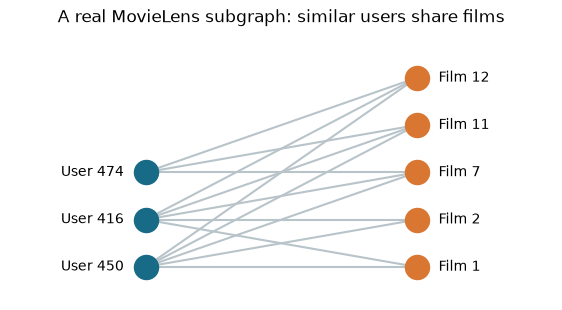

In [3]:
target_user = int(np.argmax(positive_user_item.sum(axis=1)))
overlap = positive_user_item @ positive_user_item[target_user].astype(int)
overlap[target_user] = 0
neighbor_users = np.argsort(overlap)[-2:][::-1]
shared = positive_user_item[neighbor_users].sum(axis=0) > 0
shared_items = np.flatnonzero(positive_user_item[target_user] & shared)[:5]

graph_users = np.r_[target_user, neighbor_users]
user_y = {user: row for row, user in enumerate(graph_users)}
item_y = {item: row for row, item in enumerate(shared_items)}
fig, ax = plt.subplots(figsize=(7, 3.5))
for user, y_user in user_y.items():
    for item, y_item in item_y.items():
        if positive_user_item[user, item]:
            ax.plot([0, 1], [y_user, y_item], color="#b8c4c9", zorder=1)

ax.scatter([0] * len(graph_users), list(user_y.values()), s=300, color="#176b87")
ax.scatter([1] * len(shared_items), list(item_y.values()), s=300, color="#d97732")
for user, y in user_y.items():
    ax.text(-0.08, y, f"User {USER_IDS[user]}", ha="right", va="center")
for item, y in item_y.items():
    ax.text(1.08, y, f"Film {ITEM_IDS[item]}", ha="left", va="center")
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.7, max(len(graph_users), len(shared_items)))
ax.axis("off")
plt.title("A real MovieLens subgraph: similar users share films")
plt.show()

Blue dots are users; orange dots are films. Every line is a positive rating from the training history. A user is never connected directly to another user, but two users can be linked through a film they both liked.

Chapter 3 calculated those similarities explicitly. A graph model can instead pass information along the same paths.

## From graph to matrix

### a. One edge in each direction

Let $R_{ui}=1$ when user $u$ gave film $i$ a positive rating, and 0 otherwise. The full graph has users and films as rows and columns:

```text
             users       films
A =       [   0      |    R    ]
          [  R.T     |    0    ]
```

The zero blocks mean there are no direct user-user or film-film edges. Each positive rating appears in both directions: user to film, and film to user.

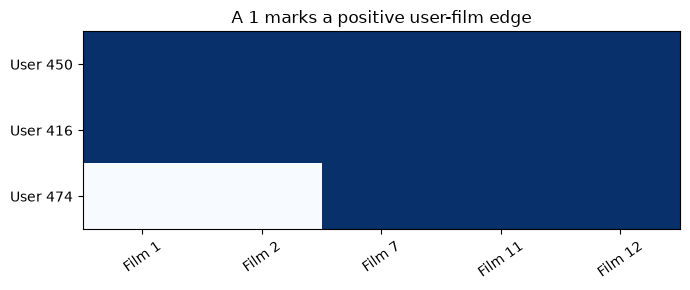

In [4]:
small_matrix = positive_user_item[np.ix_(graph_users, shared_items)].astype(int)
fig, ax = plt.subplots(figsize=(7, 3))
ax.imshow(small_matrix, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(shared_items)))
ax.set_xticklabels([f"Film {ITEM_IDS[i]}" for i in shared_items], rotation=35)
ax.set_yticks(range(len(graph_users)))
ax.set_yticklabels([f"User {USER_IDS[u]}" for u in graph_users])
ax.set_title("A 1 marks a positive user-film edge")
plt.tight_layout()
plt.show()

Each row is a user and each column is a film. A blue square means that user rated that film 4 or 5. An empty square means there is no positive edge in our graph; it does **not** prove the user disliked that film.

The full matrix has over a million possible user-film pairs but only tens of thousands of positive edges. We will store only the edges that exist.

### b. Give each edge a balanced weight

Some users rate many films; some films are very popular. Letting every neighbor send a full-strength message would let those busy nodes dominate. We scale each edge by the degrees of its two endpoints:

$$\tilde{A}_{uv} = \frac{A_{uv}}{\sqrt{d_u d_v}}$$

Here $d_u$ and $d_v$ are the numbers of edges touching the two nodes. This is called **symmetric degree normalization**.

In [5]:
num_nodes = num_users + num_items
edge_users = torch.as_tensor(positive_train_pairs[:, 0])
edge_films = torch.as_tensor(positive_train_pairs[:, 1] + num_users)
row = torch.cat((edge_users, edge_films))
col = torch.cat((edge_films, edge_users))
indices = torch.stack((row, col))

adjacency = torch.sparse_coo_tensor(
    indices, torch.ones(len(row)), (num_nodes, num_nodes)
).coalesce()
degree = torch.sparse.sum(adjacency, dim=1).to_dense()
inv_sqrt_degree = degree.clamp(min=1).rsqrt()
row, col = adjacency.indices()
weights = inv_sqrt_degree[row] * inv_sqrt_degree[col]
normalized_adjacency = torch.sparse_coo_tensor(
    adjacency.indices(), weights, adjacency.shape
).coalesce()
print(f"Graph: {num_nodes:,} nodes, {adjacency._nnz() // 2:,} edges")

Graph: 2,625 nodes, 54,889 edges


/var/folders/w3/z5ntzxbd1cj700423y73_bk80000gn/T/ipykernel_37653/3310428561.py:8: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:855.)
  adjacency = torch.sparse_coo_tensor(


## Let information travel along edges

Give every user and film a trainable vector. A propagation step replaces each vector with a weighted average of its neighbors' vectors. In matrix form:

$$E^{(1)} = \tilde{A} E^{(0)}$$

After one step, a user receives information from films they liked. After two steps, that user can also receive information from other users who liked those films. The graph controls which signals can travel.

In [6]:
embedding_dim = 32
num_layers = 2
node_embeddings = nn.Embedding(num_nodes, embedding_dim)
nn.init.normal_(node_embeddings.weight, std=0.1)
print("One vector per user and film:", tuple(node_embeddings.weight.shape))

One vector per user and film: (2625, 32)


The 2,625 rows are the users followed by the films. Each row has 32 learned numbers. Their meaning is not assigned in advance; training will adjust them so that connected users and films receive useful recommendation scores.

### a. Average the layer representations

A general graph network may transform vectors at every layer. LightGCN keeps this part simple: it only propagates and averages the vectors from all layers.

```text
final vector = (E0 + E1 + E2) / 3
```

$E_0$ keeps the node's own learned vector; $E_1$ and $E_2$ add information from one-hop and two-hop neighbors.

In [7]:
def propagate():
    layers = [node_embeddings.weight]
    for _ in range(num_layers):
        layers.append(torch.sparse.mm(normalized_adjacency, layers[-1]))
    return torch.stack(layers).mean(dim=0)

final_embeddings = propagate()
print("Final user and film vectors:", tuple(final_embeddings.shape))

Final user and film vectors: (2625, 32)


The result has one 32-number vector per node. Because the graph matrix is sparse, propagation touches only observed positive edges instead of multiplying a dense 2,625 by 2,625 matrix.

## Score a user-film pair

After propagation, compare the user's vector with a film's vector using a dot product. A larger score puts the film higher in that user's ranking. These scores are for ordering; they are not star ratings or probabilities.

In [8]:
def score_pairs(all_embeddings, users, films):
    user_vectors = all_embeddings[users]
    film_vectors = all_embeddings[num_users + films]
    return (user_vectors * film_vectors).sum(dim=1)

example_score = score_pairs(final_embeddings, torch.tensor([0]), torch.tensor([5]))
example_score

tensor([-0.0007], grad_fn=<SumBackward1>)

## Train from positive interactions

### a. Sample a film the user has not rated

MovieLens records ratings, so we know which films were liked. It does not tell us that every film a user never rated is a dislike. For training, we pair a positive rating with a film that user has not rated and ask the model to score the positive one higher.

In [9]:
train_positive = torch.as_tensor(positive_train_pairs[:, :2])
seen_train = torch.zeros((num_users, num_items), dtype=torch.bool)
train_users = torch.as_tensor(train_pairs[:, 0])
train_films = torch.as_tensor(train_pairs[:, 1])
seen_train[train_users, train_films] = True


def sample_negative_items(user_batch):
    films = torch.randint(num_items, user_batch.shape)
    seen = seen_train[user_batch, films]
    while seen.any():
        films[seen] = torch.randint(num_items, (int(seen.sum()),))
        seen = seen_train[user_batch, films]
    return films

This pairwise objective is called **BPR** (Bayesian Personalized Ranking). For one user, one positive film, and one sampled unrated film:

$$\text{loss} = \operatorname{softplus}(s_{negative} - s_{positive})$$

If the positive score is already larger, the loss is small. If the negative score is larger, the loss pushes the embeddings to correct that ordering. We also use a small weight-decay penalty to discourage very large vectors.

Here is the ranking loss in code. The positive and negative scores come from the same propagated embeddings.

In [10]:
def bpr_loss(users, positive_films, negative_films):
    embeddings = propagate()
    positive_scores = score_pairs(embeddings, users, positive_films)
    negative_scores = score_pairs(embeddings, users, negative_films)
    return torch.nn.functional.softplus(negative_scores - positive_scores).mean()

In [11]:
optimizer = torch.optim.Adam(
    node_embeddings.parameters(), lr=0.01, weight_decay=1e-4
)
training_steps, batch_size = 200, 2048
loss_history = []

for step in range(training_steps):
    rows = torch.randint(len(train_positive), (batch_size,))
    batch = train_positive[rows]
    users, positive_films = batch[:, 0], batch[:, 1]
    negative_films = sample_negative_items(users)
    loss = bpr_loss(users, positive_films, negative_films)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

print(f"BPR loss: {loss_history[0]:.3f} -> {loss_history[-1]:.3f}")

BPR loss: 0.693 -> 0.313


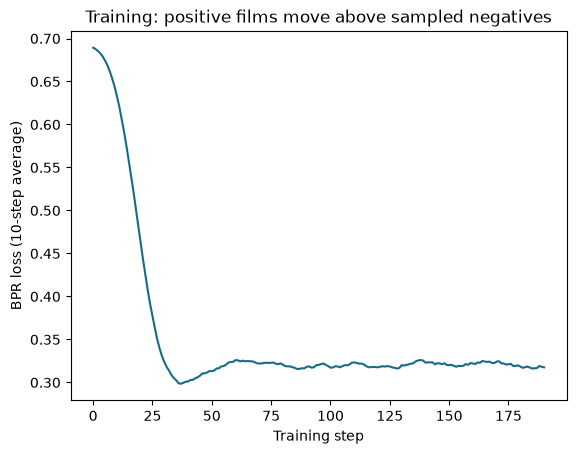

In [12]:
window = 10
smoothed_loss = np.convolve(
    loss_history, np.ones(window) / window, mode="valid"
)
plt.plot(smoothed_loss, color="#176b87")
plt.xlabel("Training step")
plt.ylabel("BPR loss (10-step average)")
plt.title("Training: positive films move above sampled negatives")
plt.show()

The moving average smooths some of the noise from sampling different training pairs at each step. Use this curve to inspect learning; use the held-out comparison below to judge recommendations.

The curve should generally go down as the model learns to rank sampled positives above sampled negatives. That is **training progress**, not proof that the next recommendations are good. For that, we need the ratings held out earlier.

## Evaluate recommendations on future ratings

Chapter 3 held out each user's latest rating and measured **HitRate@10** on held-out ratings of 4 or 5 stars. We use that same split and metric here. A hit means the held-out film appears among the user's ten highest-scoring unseen films.

We compare LightGCN with chapter 3's popularity baseline. Both methods use the same training history, hide the same already-rated films, and are tested on the same positive ratings. LightGCN scores are rankings, so rating-prediction RMSE is not the right metric here.

In [13]:
with torch.no_grad():
    final_embeddings = propagate()
    scores = final_embeddings[:num_users] @ final_embeddings[num_users:].T
    scores[seen_train] = -torch.inf
    lightgcn_top10 = scores.topk(10, dim=1).indices.cpu().numpy()

popular_counts = np.bincount(
    positive_train_pairs[:, 1], minlength=num_items
)
popular_order = np.argsort(-popular_counts, kind="stable")
seen_array = seen_train.numpy()
popular_top10 = [
    [film for film in popular_order if not seen_array[user, film]][:10]
    for user in range(num_users)
]

test_users = positive_test_pairs[:, 0].astype(int)
test_films = positive_test_pairs[:, 1].astype(int)
graph_hits = [film in lightgcn_top10[user] for user, film in zip(test_users, test_films)]
popular_hits = [film in popular_top10[user] for user, film in zip(test_users, test_films)]
results = {
    "Popularity": float(np.mean(popular_hits)),
    "LightGCN": float(np.mean(graph_hits)),
}
for name, hit_rate in results.items():
    print(f"{name}: HitRate@10 = {hit_rate:.3f}")

Popularity: HitRate@10 = 0.111
LightGCN: HitRate@10 = 0.107


These numbers use the same held-out positive ratings. The scores only rank unseen films; a higher score is not a probability.

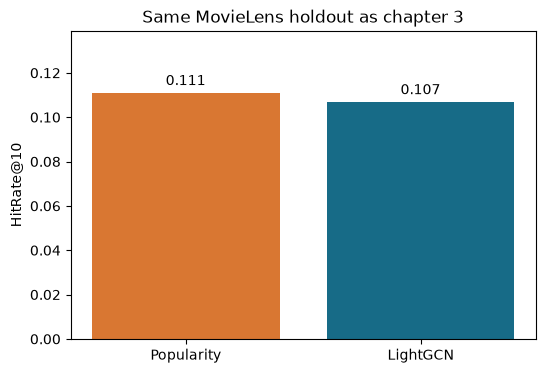

In [14]:
names = list(results)
values = [results[name] for name in names]
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(names, values, color=["#d97732", "#176b87"])
ax.set_ylabel("HitRate@10")
ax.set_title("Same MovieLens holdout as chapter 3")
ax.set_ylim(0, max(values) * 1.25)
ax.bar_label(bars, fmt="%.3f", padding=3)
plt.show()

In this run, popularity is slightly ahead. That is useful information, not a failed lesson: a graph model is not automatically better, and the training loss alone could not tell us this.

## In summary

- Chapters 2 and 3 use item features or neighborhood comparisons. LightGCN uses the same interaction history as a graph.
- Each positive user-film rating is an edge; normalized message passing carries information across one-hop and multi-hop neighbors.
- LightGCN averages the original embeddings with the embeddings produced by each graph layer.
- BPR training teaches the model to rank observed positive films above sampled unrated films.
- A falling training loss is not a performance result. We measure HitRate@10 on the same held-out positive ratings as chapter 3.

This run gives LightGCN 0.107 HitRate@10 and popularity 0.111. LightGCN does not win here. A different model size, layer count, or training setup may change the result, but only another held-out evaluation can show that.

A new user with no positive history has no useful graph representation. That is still a cold-start problem; chapter 1's bandit approach addresses a different part of that problem.

## Your turn

Try changing `num_layers` to 1 or 3. Rerun training and evaluation: does HitRate@10 move with training loss?

For the original method, see He et al., [*LightGCN: Simplifying and Powering Graph Convolution Network for Recommendation*](https://arxiv.org/abs/2002.02126), SIGIR 2020.